In [1]:
# Check for GPU

import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [2]:
# Training augmentation / Transformatio 

from torchvision import transforms
from torchvision.transforms import ToTensor

train_transform = transforms.Compose([
    transforms.RandomRotation(15),                 # Random rotation
    transforms.RandomAffine(0, scale=(0.8, 1.2)),  # Random scaling
    transforms.ToTensor(),                         # Convert to tensor
    transforms.Normalize((0.1307,), (0.3081,)),    #Normalizing
    transforms.Lambda(
        lambda x: (x + 0.2 * torch.randn_like(x)).clamp(0, 1)
    ),                                              # Add random noise
])

# Testing transformation
test_transform = transforms.ToTensor()

In [3]:
#Download Dataset

from torchvision import datasets
train_dataset = datasets.MNIST(
    root="./data",                     # Dataset location
    train=True,
    download=True,                     # Download if needed 
    transform=train_transform          # Apply transformation
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=train_transform
)

100%|██████████| 9.91M/9.91M [00:11<00:00, 884kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 84.3kB/s]
100%|██████████| 1.65M/1.65M [00:02<00:00, 682kB/s] 
100%|██████████| 4.54k/4.54k [00:00<00:00, 324kB/s]


In [4]:
# Create a custom dataset class for MNIST

from torch.utils.data import Dataset

class MNISTDataset(Dataset):
    def __init__(self, dataset):
        self.dataset = dataset

    # Return total number of samples
    def __len__(self):
        return len(self.dataset)

    # Return one image and its label
    def __getitem__(self, index):
        image, label = self.dataset[index]
        return image, label

In [5]:
# Create datasets

train_dataset = MNISTDataset(train_dataset)

test_dataset = MNISTDataset(test_dataset)

In [6]:
from torch.utils.data import random_split

# Keep only 10% of training data for hyperparameter tuning
tune_size = int(0.10 * len(train_dataset))
remaining_size = len(train_dataset) - tune_size

tune_dataset, _ = random_split(
    train_dataset,
    [tune_size, remaining_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"Training samples for tuning: {len(tune_dataset)}")

Training samples for tuning: 6000


In [7]:
# Create training dataloader

from torch.utils.data import DataLoader

BATCH_SIZE = 64

train_loader = DataLoader(
    tune_dataset,
    batch_size=BATCH_SIZE,    # Samples per batch
    shuffle=True,       # Shuffle training data
    pin_memory=True
)

# Create testing dataloader
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,    # Samples per batch
    shuffle=False,      # Keep original order
    pin_memory=True
)

Image size: 28 x 28 x 1 (H x W x C)
Number of classes: 10
Classes: 0, 1, 2, 3, 4, 5, 6, 7, 8, 9


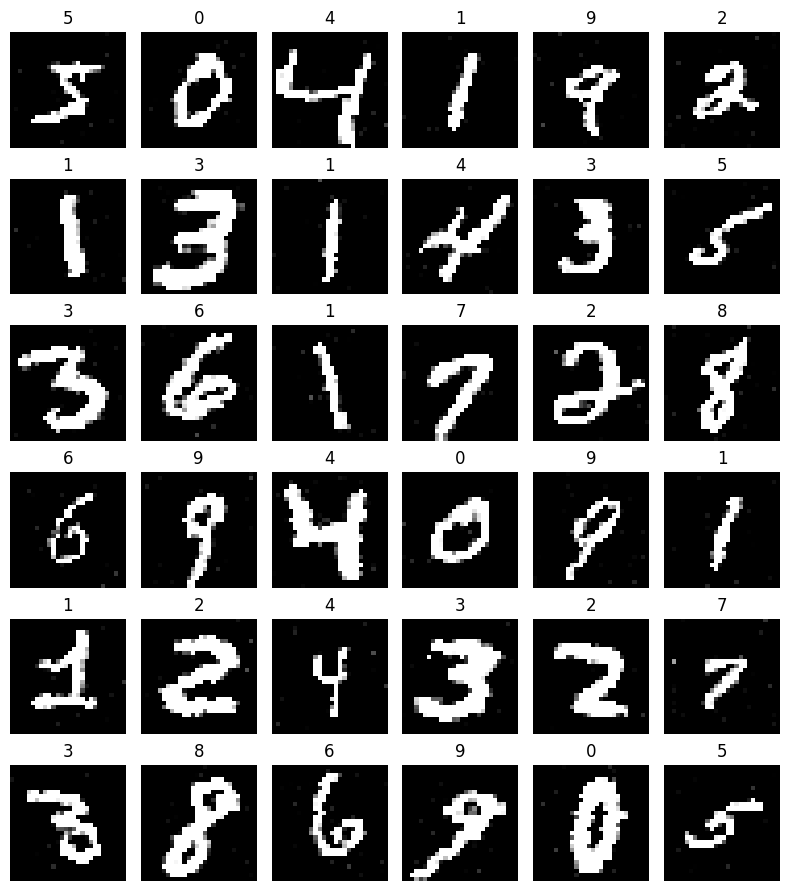

In [8]:
#Visualize Dataset

import matplotlib.pyplot as plt
import numpy as np

class Visualize:
    def __init__(self, dataset, classes):
        self.dataset = dataset
        self.classes = classes

    def plot_grid(self, num_images=36):

        """Plot a grid of MNIST images with labels."""
        
        cols = 6
        rows = int(np.ceil(num_images / cols))

        fig, axes = plt.subplots(rows, cols, figsize=(8, 1.5 * rows))
        axes = axes.flatten()

        for i in range(num_images):
            image, label = self.dataset[i]
            img_np = image.squeeze().numpy()  # Remove channel dimension

            axes[i].imshow(img_np, cmap='gray')
            axes[i].set_title(self.classes[label])
            axes[i].axis("off")

        for i in range(num_images, len(axes)):
            axes[i].axis("off")

        plt.tight_layout()
        plt.show()

    def print_metrics(self):
        """Print image size and class names."""
        image, _ = self.dataset[0]
        c, h, w = image.shape

        print(f"Image size: {h} x {w} x {c} (H x W x C)")
        print(f"Number of classes: {len(self.classes)}")
        print(f"Classes: {', '.join(self.classes)}")


# MNIST class names
mnist_classes = [
    "0", "1", "2", "3", "4",
    "5", "6", "7", "8", "9"
]

# Visualize the dataset
visualizer = Visualize(train_dataset, mnist_classes)
visualizer.print_metrics()
visualizer.plot_grid(num_images=36)

In [9]:
import torch
import torch.nn as nn

class CNN(nn.Module):

    def __init__(
        self,
        conv1_filters=32,
        conv2_filters=64,
        fc_units=64,
        dropout_rate=0.3
    ):
        super().__init__()

        # -----------------------------
        # Convolutional Layers
        # -----------------------------

        self.conv_layers = nn.Sequential(

            # Conv Layer 1
            nn.Conv2d(
                in_channels=1,
                out_channels=conv1_filters,
                kernel_size=3
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Conv Layer 2
            nn.Conv2d(
                in_channels=conv1_filters,
                out_channels=conv2_filters,
                kernel_size=3
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        # -----------------------------
        # Fully Connected Layers
        # -----------------------------

        self.fc_layers = nn.Sequential(

            nn.Flatten(),

            # Feature map size after two Conv + Pool layers:
            # 28x28 -> 26x26 -> 13x13 -> 11x11 -> 5x5

            nn.Linear(
                conv2_filters * 5 * 5,
                fc_units
            ),

            nn.ReLU(),

            nn.Dropout(dropout_rate),

            nn.Linear(
                fc_units,
                10
            )
        )

    def forward(self, x):

        x = self.conv_layers(x)

        x = self.fc_layers(x)

        return x


# Create model
model = CNN()

print(model)

CNN(
  (conv_layers): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1600, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [10]:
#set learning rate and epochs
epochs = 100
learning_rate = 0.1

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

# ======================================================
# Objective Function
# ======================================================

def objective(trial):

    # ===============================
    # Hyperparameter Search Space
    # ===============================

    conv1_filters = trial.suggest_categorical(
        "conv1_filters",
        [16, 32, 64]
    )

    conv2_filters = trial.suggest_categorical(
        "conv2_filters",
        [32, 64, 128]
    )

    fc_units = trial.suggest_categorical(
        "fc_units",
        [64, 128, 256]
    )

    dropout_rate = trial.suggest_float(
        "dropout_rate",
        0.2,
        0.5,
        step=0.1
    )

    learning_rate = trial.suggest_float(
        "learning_rate",
        1e-4,
        1e-2,
        log=True
    )

    batch_size = trial.suggest_categorical(
        "batch_size",
        [32, 64, 128]
    )

    optimizer_name = trial.suggest_categorical(
        "optimizer",
        ["Adam", "SGD", "RMSprop"]
    )

    weight_decay = trial.suggest_float(
        "weight_decay",
        1e-6,
        1e-3,
        log=True
    )

    epochs = trial.suggest_int(
        "epochs",
        10,
        30,
        step=5
    )

    # ===============================
    # Data Loader
    # ===============================

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    # ===============================
    # Model
    # ===============================

    model = CNN(
        conv1_filters=conv1_filters,
        conv2_filters=conv2_filters,
        fc_units=fc_units,
        dropout_rate=dropout_rate
    ).to(device)

    # ===============================
    # Loss Function
    # ===============================

    criterion = nn.CrossEntropyLoss()

    # ===============================
    # Optimizer
    # ===============================

    if optimizer_name == "Adam":

        optimizer = optim.Adam(
            model.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay
        )

    elif optimizer_name == "SGD":

        optimizer = optim.SGD(
            model.parameters(),
            lr=learning_rate,
            momentum=0.9,
            weight_decay=weight_decay
        )

    else:

        optimizer = optim.RMSprop(
            model.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay
        )

    # ===============================
    # Training
    # ===============================

    model.train()

    for epoch in range(epochs):

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

    # ===============================
    # Evaluation
    # ===============================

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    accuracy = correct / total

    return accuracy

In [12]:
import optuna

study = optuna.create_study(direction='maximize')

d:\Conda\envs\DL\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-07-26 18:07:18,969] A new study created in memory with name: no-name-8366ea73-536c-4600-86ce-4fbd4207ff70


In [13]:
study.optimize(objective, n_trials=10)

[I 2026-07-26 18:15:08,806] Trial 0 finished with value: 0.973 and parameters: {'conv1_filters': 16, 'conv2_filters': 64, 'fc_units': 64, 'dropout_rate': 0.5, 'learning_rate': 0.008301404844350557, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 1.4270763925178433e-06, 'epochs': 10}. Best is trial 0 with value: 0.973.
[I 2026-07-26 18:26:13,215] Trial 1 finished with value: 0.9743 and parameters: {'conv1_filters': 16, 'conv2_filters': 32, 'fc_units': 128, 'dropout_rate': 0.5, 'learning_rate': 0.0021318565668449595, 'batch_size': 128, 'optimizer': 'SGD', 'weight_decay': 0.0005577303688618252, 'epochs': 20}. Best is trial 1 with value: 0.9743.
[I 2026-07-26 18:44:28,907] Trial 2 finished with value: 0.9881 and parameters: {'conv1_filters': 64, 'conv2_filters': 32, 'fc_units': 256, 'dropout_rate': 0.30000000000000004, 'learning_rate': 0.007430299350890381, 'batch_size': 128, 'optimizer': 'SGD', 'weight_decay': 2.030604634758722e-05, 'epochs': 30}. Best is trial 2 with value: 0.9881

In [14]:
study.best_value

0.9881

In [15]:
study.best_params

{'conv1_filters': 64,
 'conv2_filters': 32,
 'fc_units': 256,
 'dropout_rate': 0.30000000000000004,
 'learning_rate': 0.007430299350890381,
 'batch_size': 128,
 'optimizer': 'SGD',
 'weight_decay': 2.030604634758722e-05,
 'epochs': 30}

In [24]:
#instatiate the model
best_params = study.best_params


train_loader = DataLoader(
    train_dataset,
    batch_size=best_params["batch_size"],
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=best_params["batch_size"],
    shuffle=False
)


model = CNN(
    conv1_filters=best_params["conv1_filters"],
    conv2_filters=best_params["conv2_filters"],
    fc_units=best_params["fc_units"],
    dropout_rate=best_params["dropout_rate"]
).to(device)

#loss function
criterion = torch.nn.CrossEntropyLoss()

#optimizer
if best_params["optimizer"] == "Adam":

    optimizer = optim.Adam(
        model.parameters(),
        lr=best_params["learning_rate"],
        weight_decay=best_params["weight_decay"]
    )

elif best_params["optimizer"] == "SGD":

    optimizer = optim.SGD(
        model.parameters(),
        lr=best_params["learning_rate"],
        momentum=0.9,
        weight_decay=best_params["weight_decay"]
    )

else:

    optimizer = optim.RMSprop(
        model.parameters(),
        lr=best_params["learning_rate"],
        weight_decay=best_params["weight_decay"]
    ) 

In [25]:
# Training loop
import os
import torch
from tqdm import tqdm

# Ensure Models directory exists
os.makedirs("Models", exist_ok=True)

epochs = best_params.get("epochs", 20)

for epoch in range(1, epochs + 1):
    # Extract current learning rate
    current_lr = optimizer.param_groups[0]["lr"]
    
    # Header
    print(f"Epoch [{epoch}/{epochs}] | Learning Rate: {current_lr:.6f}\n")
    
    # Training Phase
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    train_pbar = tqdm(train_loader, desc="Training", leave=True)
    for images, labels in train_pbar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        batch_size = labels.size(0)
        train_loss += loss.item() * batch_size
        _, predicted = torch.max(outputs.data, 1)
        train_correct += (predicted == labels).sum().item()
        train_total += batch_size
        
        running_acc = (train_correct / train_total) * 100
        running_loss = train_loss / train_total
        train_pbar.set_postfix(acc=f"{running_acc:.1f}", loss=f"{running_loss:.3f}")
        
    epoch_train_loss = train_loss / train_total
    epoch_train_acc = (train_correct / train_total) * 100
    
    print()
    
    # Testing Phase
    model.eval()
    test_loss = 0.0
    test_correct = 0
    test_total = 0
    
    test_pbar = tqdm(test_loader, desc="Testing", leave=True)
    with torch.no_grad():
        for images, labels in test_pbar:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            batch_size = labels.size(0)
            test_loss += loss.item() * batch_size
            _, predicted = torch.max(outputs.data, 1)
            test_correct += (predicted == labels).sum().item()
            test_total += batch_size
            
    epoch_test_loss = test_loss / test_total
    epoch_test_acc = (test_correct / test_total) * 100
    
    # Summary & Save Checkpoint
    print()
    print(f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}%")
    print(f"Test Loss:  {epoch_test_loss:.4f} | Test Acc: {epoch_test_acc:.2f}%\n")
    
    checkpoint_path = f"Models/cnn_epoch_{epoch}.pth"
    torch.save(model.state_dict(), checkpoint_path)
    print(f"--> Saved model checkpoint to {checkpoint_path}\n")


Epoch [1/30] | Learning Rate: 0.007430



Training: 100%|██████████| 469/469 [00:55<00:00,  8.52it/s, acc=77.6, loss=0.691]


Testing: 100%|██████████| 79/79 [00:07<00:00, 10.15it/s]



Train Loss: 0.6914 | Train Acc: 77.61%
Test Loss:  0.1865 | Test Acc: 94.08%

--> Saved model checkpoint to Models/cnn_epoch_1.pth

Epoch [2/30] | Learning Rate: 0.007430



Training: 100%|██████████| 469/469 [00:54<00:00,  8.66it/s, acc=94.2, loss=0.188]


...

Testing: 100%|██████████| 79/79 [00:11<00:00,  7.01it/s]



Train Loss: 0.0432 | Train Acc: 98.60%
Test Loss:  0.0390 | Test Acc: 98.79%

--> Saved model checkpoint to Models/cnn_epoch_29.pth

Epoch [30/30] | Learning Rate: 0.007430



Training: 100%|██████████| 469/469 [01:11<00:00,  6.59it/s, acc=98.6, loss=0.044]


Testing: 100%|██████████| 79/79 [00:11<00:00,  6.99it/s]


Train Loss: 0.0435 | Train Acc: 98.63%
Test Loss:  0.0419 | Test Acc: 98.73%

--> Saved model checkpoint to Models/cnn_epoch_30.pth



In [26]:
#set model to eval mode
model.eval()

CNN(
  (conv_layers): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=800, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.30000000000000004, inplace=False)
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)

In [27]:
#evaluationn code

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 98.86%


In [30]:
#fine tunning

import torch

def fine_tune(model, model_path, lr=1e-4, epochs=10):

    # Load pretrained model
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)

    print(f"Loaded model from {model_path}")
    print(f"Fine-tuning with learning rate = {lr}")

    # New optimizer with lower learning rate
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=1e-4
    )

    for epoch in range(1, epochs + 1):

        current_lr = optimizer.param_groups[0]["lr"]

        print(f"Epoch [{epoch}/{epochs}] | Learning Rate: {current_lr:.6f}\n")

        # Training
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        train_pbar = tqdm(train_loader, desc="Training", leave=True)

        for images, labels in train_pbar:

            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            batch_size = labels.size(0)

            train_loss += loss.item() * batch_size

            _, predicted = torch.max(outputs.data, 1)

            train_correct += (predicted == labels).sum().item()

            train_total += batch_size

            running_acc = (train_correct / train_total) * 100
            running_loss = train_loss / train_total

            train_pbar.set_postfix(
                acc=f"{running_acc:.1f}",
                loss=f"{running_loss:.3f}"
            )

        epoch_train_loss = train_loss / train_total
        epoch_train_acc = (train_correct / train_total) * 100

        print()

        # Testing
        model.eval()

        test_loss = 0.0
        test_correct = 0
        test_total = 0

        test_pbar = tqdm(test_loader, desc="Testing", leave=True)

        with torch.no_grad():

            for images, labels in test_pbar:

                images, labels = images.to(device), labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)

                batch_size = labels.size(0)

                test_loss += loss.item() * batch_size

                _, predicted = torch.max(outputs.data, 1)

                test_correct += (predicted == labels).sum().item()

                test_total += batch_size

        epoch_test_loss = test_loss / test_total
        epoch_test_acc = (test_correct / test_total) * 100

        print()
        print(f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}%")
        print(f"Test Loss:  {epoch_test_loss:.4f} | Test Acc: {epoch_test_acc:.2f}%\n")
        checkpoint_path = f"Models/cnn_epoch_{epoch}.pth"
        torch.save(model.state_dict(), checkpoint_path)
        print(f"--> Saved model checkpoint to {checkpoint_path}\n")

In [32]:
fine_tune(
    model=model,
    model_path="best_model.pth",
    lr=0.0001,
    epochs=10
)

Loaded model from best_model.pth
Fine-tuning with learning rate = 0.0001
Epoch [1/10] | Learning Rate: 0.000100



Training: 100%|██████████| 469/469 [00:46<00:00, 10.04it/s, acc=98.7, loss=0.042]


Testing: 100%|██████████| 79/79 [00:07<00:00, 11.10it/s]



Train Loss: 0.0416 | Train Acc: 98.68%
Test Loss:  0.0370 | Test Acc: 98.68%

--> Saved model checkpoint to Models/cnn_epoch_1.pth

Epoch [2/10] | Learning Rate: 0.000100



Training: 100%|██████████| 469/469 [00:45<00:00, 10.28it/s, acc=98.7, loss=0.040]


...

Testing: 100%|██████████| 79/79 [00:06<00:00, 11.84it/s]



Train Loss: 0.0360 | Train Acc: 98.83%
Test Loss:  0.0333 | Test Acc: 98.90%

--> Saved model checkpoint to Models/cnn_epoch_9.pth

Epoch [10/10] | Learning Rate: 0.000100



Training: 100%|██████████| 469/469 [00:41<00:00, 11.32it/s, acc=98.8, loss=0.036]


Testing: 100%|██████████| 79/79 [00:05<00:00, 13.24it/s]


Train Loss: 0.0360 | Train Acc: 98.81%
Test Loss:  0.0326 | Test Acc: 99.05%

--> Saved model checkpoint to Models/cnn_epoch_10.pth

